# ADS 502 Final Team Project: Spaceship Titanic

**Source:** Kaggle's Spaceship Titanic Competition 
<br>**Team members:** Aishwarya Kuduvalli and Brandon Rodriguez-Andrade

## Libraries + data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import graphviz

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

In [2]:
#Filtering out warnings

import warnings
warnings.filterwarnings('ignore')

In [3]:
#Loading in the dataset

df = pd.read_csv('spaceshiptitanic.csv')
df.shape

(8693, 14)

There are 8,693 records and 14 columns in the dataset.

In [4]:
#75/25 Train and test split 

train, test = train_test_split(df, test_size=0.25, random_state=42)
train.shape

(6519, 14)

In [5]:
test.shape

(2174, 14)

The dataset was partitioned correctly - 75% in train, 25% in test. 

In [6]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
5623,5981_01,Mars,False,F/1140/S,TRAPPIST-1e,27.0,False,441.0,0.0,397.0,471.0,0.0,Harz Quart,False
5253,5606_01,Europa,True,B/213/S,55 Cancri e,45.0,False,0.0,0.0,0.0,0.0,0.0,Algor Paterpad,True
478,0515_01,Europa,True,B/20/S,TRAPPIST-1e,50.0,False,0.0,0.0,0.0,0.0,0.0,Alramix Swinvul,True
1352,1425_02,Earth,True,G/220/P,TRAPPIST-1e,1.0,False,0.0,0.0,0.0,0.0,0.0,Mael Adavisons,True
5344,5713_01,Earth,False,G/915/P,TRAPPIST-1e,42.0,False,0.0,29.0,317.0,434.0,45.0,Lawren Blangibson,True


## Exploratory Data Analysis (EDA)

### Number of rows and columns

In [7]:
train.shape

(6519, 14)

### Column names, non-null count, data type

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6519 entries, 5623 to 7270
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6519 non-null   object 
 1   HomePlanet    6364 non-null   object 
 2   CryoSleep     6354 non-null   object 
 3   Cabin         6369 non-null   object 
 4   Destination   6387 non-null   object 
 5   Age           6377 non-null   float64
 6   VIP           6360 non-null   object 
 7   RoomService   6399 non-null   float64
 8   FoodCourt     6386 non-null   float64
 9   ShoppingMall  6365 non-null   float64
 10  Spa           6394 non-null   float64
 11  VRDeck        6384 non-null   float64
 12  Name          6371 non-null   object 
 13  Transported   6519 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 719.4+ KB


### Class distribution

In [9]:
train['Transported'].value_counts()

Transported
True     3286
False    3233
Name: count, dtype: int64

In [10]:
#Checking proportions of Transported

classdistribution = train['Transported'].value_counts(normalize=True) * 100
print(classdistribution.round(2).astype(str) + '%')

Transported
True     50.41%
False    49.59%
Name: proportion, dtype: object


Proportions of the Transported response variable reveal a balanced class distribution. 

### Descriptive Statistics

In [11]:
descstats = train.describe(include='all').round(3).fillna('-')
descstats

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,6519,6364,6354,6369,6387,6377.0,6360,6399.0,6386.0,6365.0,6394.0,6384.0,6371,6519
unique,6519,3,2,5152,3,-,2,-,-,-,-,-,6363,2
top,5981_01,Earth,False,G/734/S,TRAPPIST-1e,-,False,-,-,-,-,-,Gollux Reedall,True
freq,1,3458,4102,7,4426,-,6215,-,-,-,-,-,2,3286
mean,-,-,-,-,-,28.85,-,222.61,460.503,175.153,315.067,307.744,-,-
std,-,-,-,-,-,14.51,-,674.33,1589.108,620.597,1119.024,1181.951,-,-
min,-,-,-,-,-,0.0,-,0.0,0.0,0.0,0.0,0.0,-,-
25%,-,-,-,-,-,19.0,-,0.0,0.0,0.0,0.0,0.0,-,-
50%,-,-,-,-,-,27.0,-,0.0,0.0,0.0,0.0,0.0,-,-
75%,-,-,-,-,-,38.0,-,45.5,86.0,29.0,60.0,52.0,-,-


Some notes:
- Median in all 5 amenities is 0 -> significant proportion of individuals in CryoSleep 
- Range of spending in amenities is wide
- Age skews younger (mean 29 and median 27) 
- 54.33% of passengers are from Earth
- 69.30% of passengers have a destination of TRAPPIST-1e

### Check nulls

In [12]:
train.isnull().sum()

PassengerId       0
HomePlanet      155
CryoSleep       165
Cabin           150
Destination     132
Age             142
VIP             159
RoomService     120
FoodCourt       133
ShoppingMall    154
Spa             125
VRDeck          135
Name            148
Transported       0
dtype: int64

In [13]:
test.isnull().sum()

PassengerId      0
HomePlanet      46
CryoSleep       52
Cabin           49
Destination     50
Age             37
VIP             44
RoomService     61
FoodCourt       50
ShoppingMall    54
Spa             58
VRDeck          53
Name            52
Transported      0
dtype: int64

There are null values in 12 columns, which must be addressed during cleaning/pre-processing to ensure model compatibility. 

### Check duplicates

In [14]:
train.duplicated().sum()

np.int64(0)

In [15]:
test.duplicated().sum()

np.int64(0)

No duplicates, so rows need not be dropped. 

### Check invalid numbers

In [16]:
numericals = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
invalidnums = {}

for col in numericals:
    if col == 'Age':
        invalid = (train[col] < 0) | (train[col] > 120)
    else:
        invalid = train[col] < 0
    invalidnums[col] = invalid.sum()

invalidnums = pd.Series(invalidnums)
invalidnums

Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

No invalid (impossible) numerical values.

### Check outliers

In [17]:
outliers = {}

for col in numericals:
    mean = train[col].mean()
    std = train[col].std()
    zscore = (train[col] - mean) / std
    outliers[col] = (abs(zscore) > 3).sum()

outliers = pd.Series(outliers)
outliers

Age              20
RoomService     117
FoodCourt       125
ShoppingMall     96
Spa             138
VRDeck          120
dtype: int64

There are outliers, but we will assume they are a reflection of passengers' real spending habits. 

### Histograms with overlay

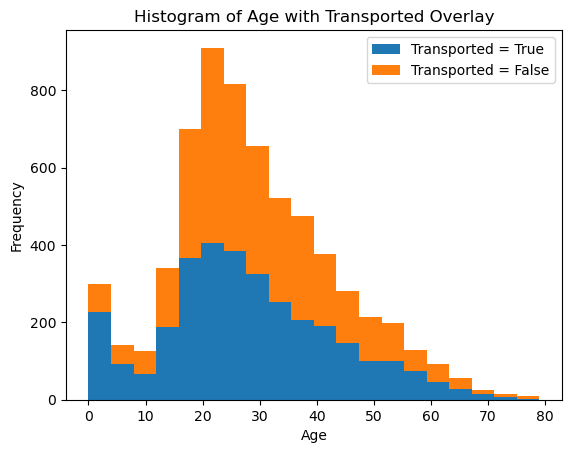

In [18]:
#Age vs. Transported histogram

age_t = train[train['Transported'] == True]['Age']
age_f = train[train['Transported'] == False]['Age']

plt.hist([age_t, age_f], bins=20, stacked=True)
plt.legend(['Transported = True', 'Transported = False'])
plt.title('Histogram of Age with Transported Overlay')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

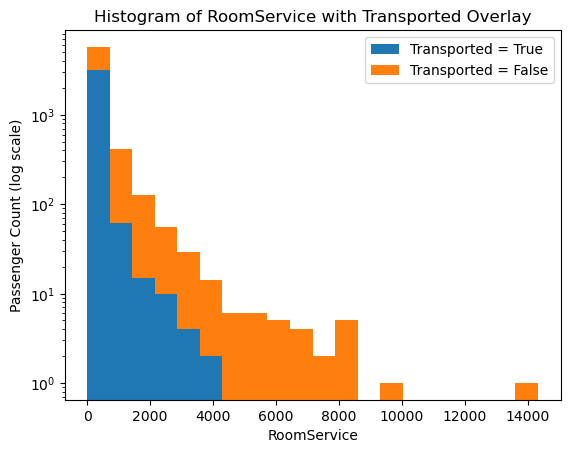

In [19]:
#RoomService vs. Transported histogram

roomservice_t = train[train['Transported'] == True]['RoomService']
roomservice_f = train[train['Transported'] == False]['RoomService']

plt.hist([roomservice_t, roomservice_f], bins=20, stacked=True, log=True)
plt.legend(['Transported = True', 'Transported = False'])
plt.title('Histogram of RoomService with Transported Overlay')
plt.xlabel('RoomService')
plt.ylabel('Passenger Count (log scale)')
plt.show()

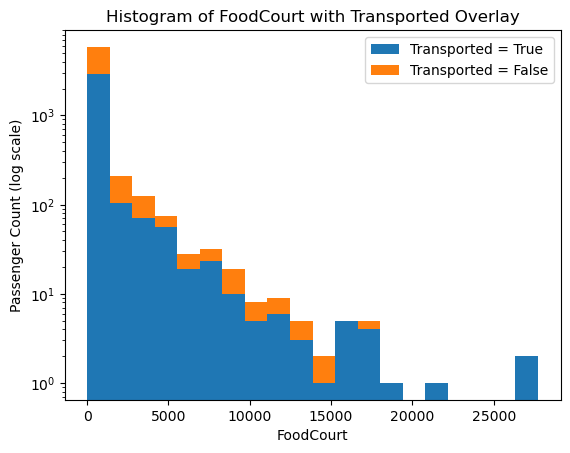

In [20]:
#FoodCourt vs. Transported histogram

foodcourt_t = train[train['Transported'] == True]['FoodCourt']
foodcourt_f = train[train['Transported'] == False]['FoodCourt']

plt.hist([foodcourt_t, foodcourt_f], bins=20, stacked=True, log=True)
plt.legend(['Transported = True', 'Transported = False'])
plt.title('Histogram of FoodCourt with Transported Overlay')
plt.xlabel('FoodCourt')
plt.ylabel('Passenger Count (log scale)')
plt.show()

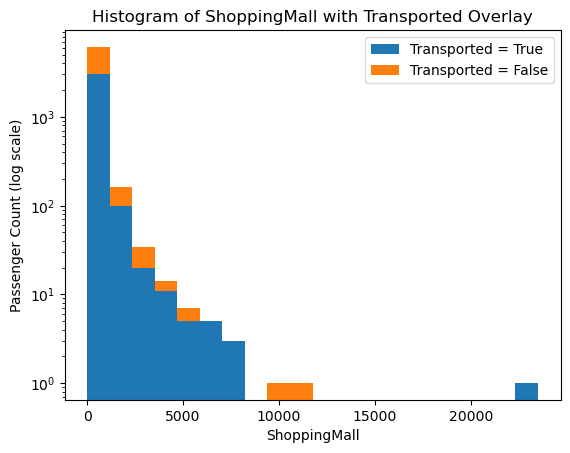

In [21]:
#ShoppingMall vs. Transported histogram

shoppingmall_t = train[train['Transported'] == True]['ShoppingMall']
shoppingmall_f = train[train['Transported'] == False]['ShoppingMall']

plt.hist([shoppingmall_t, shoppingmall_f], bins=20, stacked=True, log=True)
plt.legend(['Transported = True', 'Transported = False'])
plt.title('Histogram of ShoppingMall with Transported Overlay')
plt.xlabel('ShoppingMall')
plt.ylabel('Passenger Count (log scale)')
plt.show()

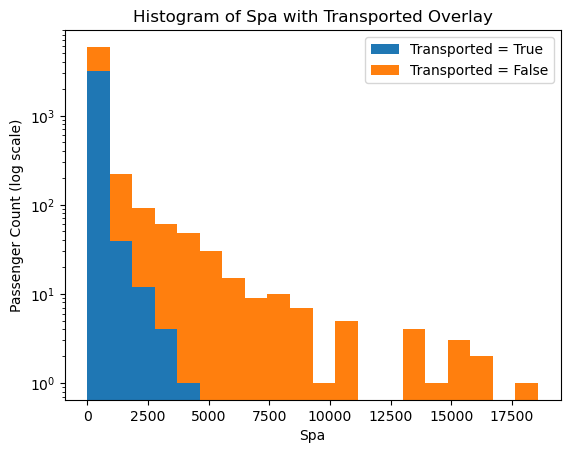

In [22]:
#Spa vs. Transported histogram

spa_t = train[train['Transported'] == True]['Spa']
spa_f = train[train['Transported'] == False]['Spa']

plt.hist([spa_t, spa_f], bins=20, stacked=True, log=True)
plt.legend(['Transported = True', 'Transported = False'])
plt.title('Histogram of Spa with Transported Overlay')
plt.xlabel('Spa')
plt.ylabel('Passenger Count (log scale)')
plt.show()

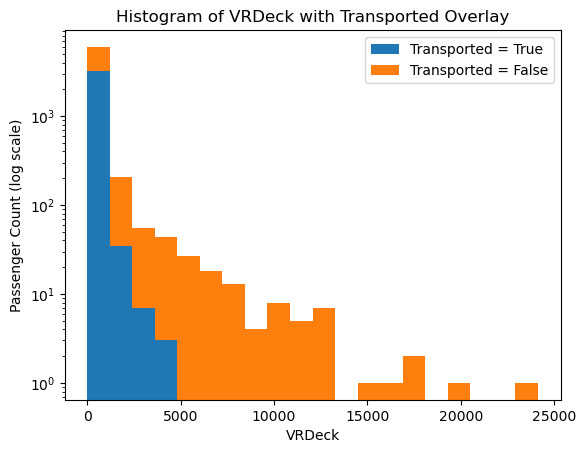

In [23]:
#VRDeck vs. Transported histogram

vrdeck_t = train[train['Transported'] == True]['VRDeck']
vrdeck_f = train[train['Transported'] == False]['VRDeck']

plt.hist([vrdeck_t, vrdeck_f], bins=20, stacked=True, log=True)
plt.legend(['Transported = True', 'Transported = False'])
plt.title('Histogram of VRDeck with Transported Overlay')
plt.xlabel('VRDeck')
plt.ylabel('Passenger Count (log scale)')
plt.show()

Some notes:
- Most histogram distributions are heavily right-skewed (except for age which is mildly right skewed).
- Large proportion of passenger have little to not spending, they also appear to have a higher likelihood of being transported
- Higher spending = higher likelihood of not being transported, potential inverse correlation here
- Some amenity variables like FoodCourt and ShoppingMall have clear class separation, age not so much (potentially more and less correlation, respectively)

### Bar graphs with overlay

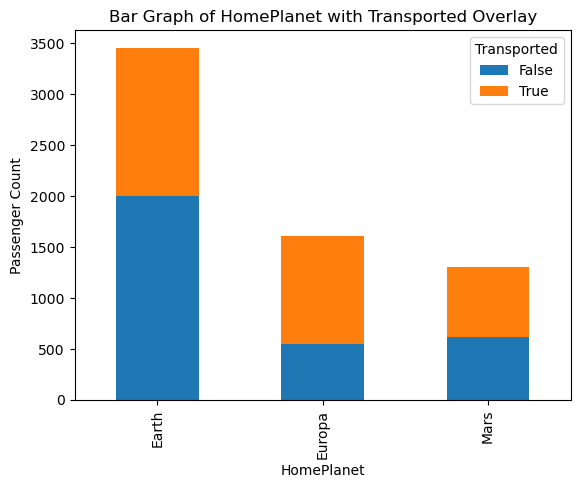

In [24]:
#Home Planet vs. Transported overlaid barplot

crosstab_homeplanet = pd.crosstab(train['HomePlanet'], train['Transported'])
crosstab_homeplanet.plot(kind='bar', stacked=True)

plt.title('Bar Graph of HomePlanet with Transported Overlay')
plt.xlabel('HomePlanet')
plt.ylabel('Passenger Count')
plt.show()

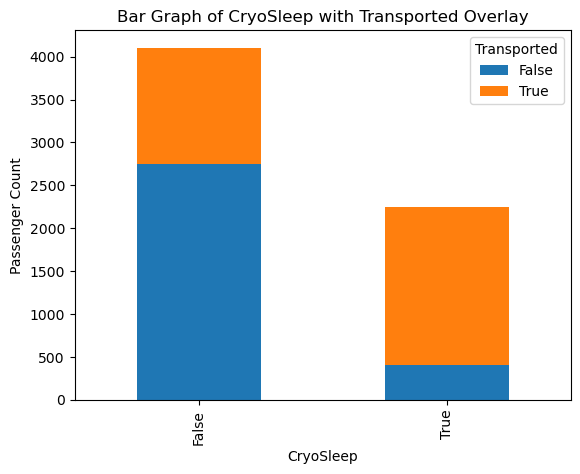

In [25]:
#CryoSleep vs. Transported overlaid barplot

crosstab_cryosleep = pd.crosstab(train['CryoSleep'], train['Transported'])
crosstab_cryosleep.plot(kind='bar', stacked=True)

plt.title('Bar Graph of CryoSleep with Transported Overlay')
plt.xlabel('CryoSleep')
plt.ylabel('Passenger Count')
plt.show()

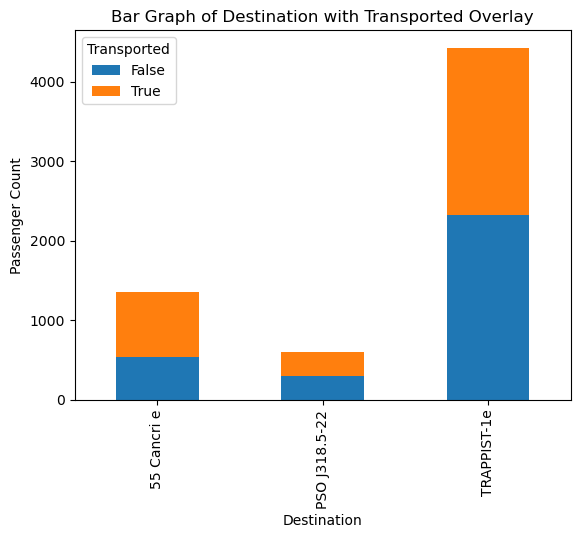

In [26]:
#Destination vs. Transported overlaid barplot

crosstab_destination = pd.crosstab(train['Destination'], train['Transported'])
crosstab_destination.plot(kind='bar', stacked=True)

plt.title('Bar Graph of Destination with Transported Overlay')
plt.xlabel('Destination')
plt.ylabel('Passenger Count')
plt.show()

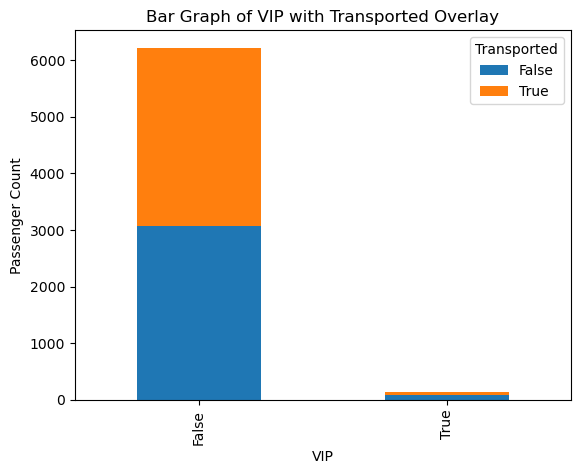

In [27]:
#VIP vs. Transported overlaid barplot

crosstab_vip = pd.crosstab(train['VIP'], train['Transported'])
crosstab_vip.plot(kind='bar', stacked=True)

plt.title('Bar Graph of VIP with Transported Overlay')
plt.xlabel('VIP')
plt.ylabel('Passenger Count')
plt.show()

- CryoSleep has greater class separation, possibly higher correlation with Transported
- Passengers with a home planet of Europa are more likely to be transported
- Not as much class separation in Destination, but more likely to be transported if destination is 55 Cancri e

### Correlation Heatmap

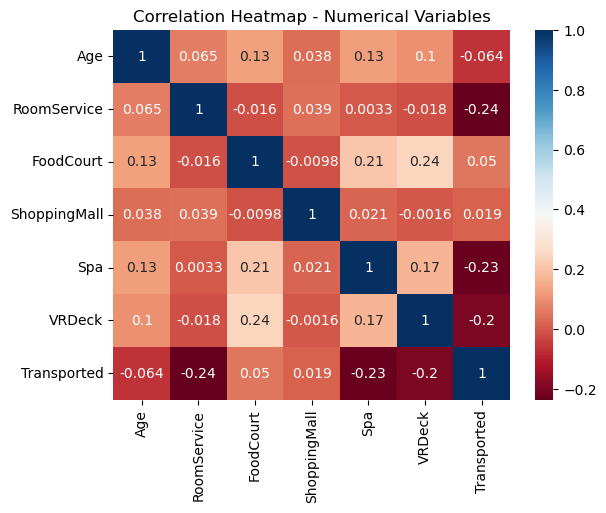

In [28]:
#Creating correlation heatmap of features to determine importance

temporarytrain = train.copy()
temporarytrain['Transported'] = temporarytrain['Transported'].astype(int)
numericals.append('Transported')

sns.heatmap(temporarytrain[numericals].corr(), annot=True, cmap='RdBu')
plt.title('Correlation Heatmap - Numerical Variables')
plt.show()

- None of the variables show significant correlation with Transported
- Strongest relationships with Transported are with Roomservice (r = -0.24) and Spa (r = -0.23) - negative correlation
- Age has the lowest correlation, in line with previous findings

## Data Pre-processing

### Extracting features from Cabin

In [29]:
#Train

cabin = train['Cabin'].str.split('/', expand=True)
train['Deck'] = cabin[0]
train['CabinNumber'] = pd.to_numeric(cabin[1], errors='coerce')
train['Side'] = cabin[2]

#Test

cabin_test = test['Cabin'].str.split('/', expand=True)
test['Deck'] = cabin_test[0]
test['CabinNumber'] = pd.to_numeric(cabin_test[1], errors='coerce')
test['Side'] = cabin_test[2]

### Drop unnecessary columns

In [30]:
#Removing Cabin (extracted) and unique identifier features

train = train.drop(columns=['Cabin', 'PassengerId', 'Name'])
test  = test.drop(columns=['Cabin', 'PassengerId', 'Name'])

In [31]:
train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNumber,Side
5623,Mars,False,TRAPPIST-1e,27.0,False,441.0,0.0,397.0,471.0,0.0,False,F,1140.0,S
5253,Europa,True,55 Cancri e,45.0,False,0.0,0.0,0.0,0.0,0.0,True,B,213.0,S
478,Europa,True,TRAPPIST-1e,50.0,False,0.0,0.0,0.0,0.0,0.0,True,B,20.0,S
1352,Earth,True,TRAPPIST-1e,1.0,False,0.0,0.0,0.0,0.0,0.0,True,G,220.0,P
5344,Earth,False,TRAPPIST-1e,42.0,False,0.0,29.0,317.0,434.0,45.0,True,G,915.0,P


Extracting features from Cabin, then dropping Cabin + unique identifier variables as they provide little use to the models.

### Fill blank amenities with 0, and assume all 0s in amenities = CryoSleep

In [32]:
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

#Train

train[amenities] = train[amenities].fillna(0)
zeroamenities = (train[amenities] == 0).all(axis=1)
train['CryoSleep'] = train['CryoSleep'].fillna(zeroamenities.astype(bool))

#Test

test[amenities] = test[amenities].fillna(0)
zeroamenities_test = (test[amenities] == 0).all(axis=1)
test['CryoSleep'] = test['CryoSleep'].fillna(zeroamenities_test.astype(bool))

Here, we assume CryoSleep = no spending in amenities, and no spending in amenities = CryoSleep.

### Categorical variables - mode imputation

In [33]:
for col in ['HomePlanet', 'Destination', 'Deck', 'Side', 'VIP']:
    modes = train[col].mode()[0]
    train[col] = train[col].fillna(modes)
    test[col] = test[col].fillna(modes)

Nulls in the test data are imputed with the modes from the training data.

### Numerical variables - median imputation

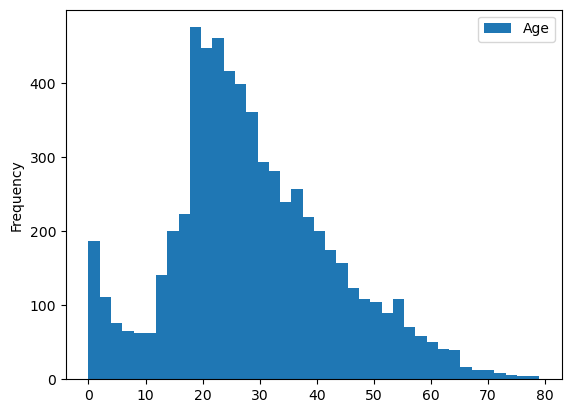

In [34]:
# Checking distribution to determine imputation method

train[['Age']].plot(kind='hist', bins=40)
plt.show()

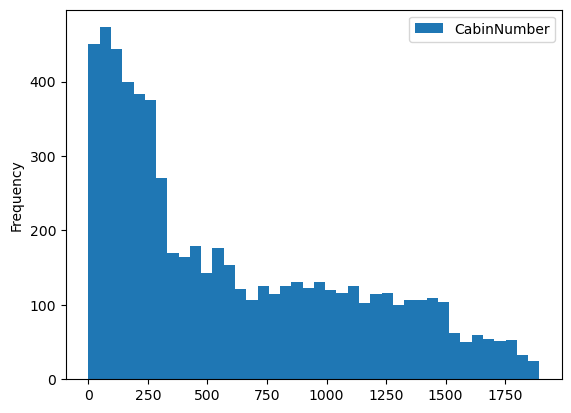

In [35]:
train[['CabinNumber']].plot(kind='hist', bins=40)
plt.show()

Both 'Age' and 'CabinNumber' are right-skewed, so median imputation is appropriate to address null values.

In [36]:
#Age

train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(train['Age'].median())

#Cabin number

train['CabinNumber'] = train['CabinNumber'].fillna(train['CabinNumber'].median())
test['CabinNumber'] = test['CabinNumber'].fillna(train['CabinNumber'].median())

In [37]:
#Re-check nulls

train.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
CabinNumber     0
Side            0
dtype: int64

In [38]:
test.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
CabinNumber     0
Side            0
dtype: int64

### Encoding categorical variables

In [39]:
#Boolean encoding

train['CryoSleep'] = train['CryoSleep'].astype(int)
train['VIP'] = train['VIP'].astype(int)

test['CryoSleep'] = test['CryoSleep'].astype(int)
test['VIP'] = test['VIP'].astype(int)

train['Transported'] = train['Transported'].astype(int)
test['Transported'] = test['Transported'].astype(int)

#One-hot encoding remaining categorical variables

categoricals = ['HomePlanet', 'Destination', 'Deck', 'Side']

train = pd.get_dummies(train, columns=categoricals, dtype=int)
test = pd.get_dummies(test, columns=categoricals, dtype=int)

train, test = train.align(test, join='left', axis=1, fill_value=0)

In [40]:
train.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,CabinNumber,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
5623,0,27.0,0,441.0,0.0,397.0,471.0,0.0,0,1140.0,...,0,0,0,0,0,1,0,0,0,1
5253,1,45.0,0,0.0,0.0,0.0,0.0,0.0,1,213.0,...,0,1,0,0,0,0,0,0,0,1
478,1,50.0,0,0.0,0.0,0.0,0.0,0.0,1,20.0,...,0,1,0,0,0,0,0,0,0,1
1352,1,1.0,0,0.0,0.0,0.0,0.0,0.0,1,220.0,...,0,0,0,0,0,0,1,0,1,0
5344,0,42.0,0,0.0,29.0,317.0,434.0,45.0,1,915.0,...,0,0,0,0,0,0,1,0,1,0


In [41]:
test.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,CabinNumber,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
304,0,19.0,0,417.0,349.0,634.0,3.0,1057.0,1,63.0,...,0,0,0,0,0,1,0,0,0,1
2697,0,18.0,0,4.0,904.0,0.0,0.0,1.0,0,460.0,...,0,0,0,0,0,0,1,0,0,1
8424,1,41.0,0,0.0,0.0,0.0,0.0,0.0,0,1449.0,...,0,0,0,0,0,0,1,0,0,1
1672,0,35.0,0,0.0,338.0,436.0,0.0,0.0,1,291.0,...,0,0,0,0,0,0,1,0,1,0
8458,1,43.0,0,0.0,0.0,0.0,0.0,0.0,1,288.0,...,0,0,0,1,0,0,0,0,1,0


Now, the data has been cleaned and pre-processed, and is now ready for feature selection. 

## Modelling

### Feature Importance with Decision Tree

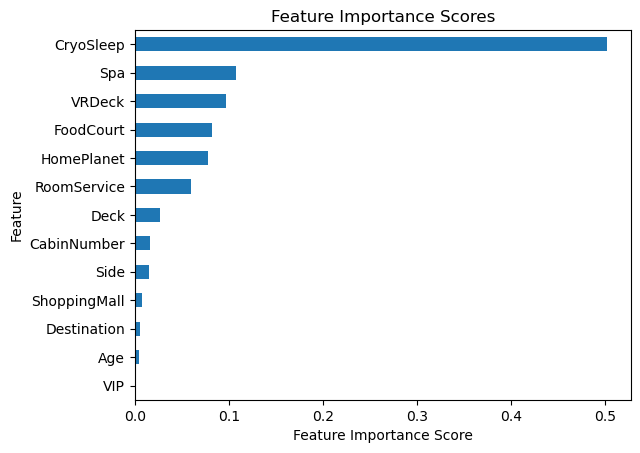

In [42]:
y = train[['Transported']]
X = train.drop(columns=['Transported'])

decisiontree = DecisionTreeClassifier(max_depth=5, random_state=42)
decisiontree.fit(X, y)

#Regrouping by original columns

originals = pd.Series(X.columns.str.split('_').str[0], index=X.columns)
featureimportance = pd.Series(decisiontree.feature_importances_, index=X.columns)
groupedbyoriginal = featureimportance.groupby(originals).sum().sort_values(ascending=False)

groupedbyoriginal.sort_values().plot(kind='barh')
plt.title('Feature Importance Scores')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()

Based on the results of the feature importance scores and the visualizations, the variables to be retained for the models include: CryoSleep, Spa, VRDeck, FoodCourt, HomePlanet, RoomService, Deck, CabinNumber, Side.

### Feature Selection

In [43]:
train = train.drop(columns=['Destination_PSO J318.5-22',
                                    'Destination_TRAPPIST-1e',
                                    'Destination_55 Cancri e',
                                    'ShoppingMall', 'Age', 'VIP'])
test = test.drop(columns=['Destination_PSO J318.5-22',
                                    'Destination_TRAPPIST-1e',
                                    'Destination_55 Cancri e',
                                    'ShoppingMall', 'Age', 'VIP'])

### Predictors and target variables

In [44]:
#Train

y = y = train[['Transported']]
X = train.drop(columns=['Transported'])

#Test

y_test = test['Transported']
X_test = test.drop(columns=['Transported'])

y = target variable, X = predictors

### Baseline

In [45]:
y_test.value_counts()

Transported
1    1092
0    1082
Name: count, dtype: int64

Baseline = All-positive (based on class distribution, more transported than not transported)

In [46]:
tn_base = 0
tp_base = 1092
fn_base = 0
fp_base = 1082

gt_base = tn_base + tp_base + fn_base + fp_base

In [47]:
#Evaluation metrics

accuracy_base = (tp_base + tn_base) / gt_base
errorrate_base = 1 - accuracy_base
sensitivity_base = tp_base / (tp_base + fn_base)
specificity_base = tn_base / (tn_base + fp_base)
precision_base = tp_base / (tp_base + fp_base)
f1_base = 2 * ((precision_base * sensitivity_base) / (precision_base + sensitivity_base))
f2_base = 5 * ((precision_base * sensitivity_base) / ((4 * precision_base) + sensitivity_base))
f05_base = 1.25 * ((precision_base * sensitivity_base) / ((0.25 * precision_base) + sensitivity_base))

### CART

In [48]:
X_names = list(X.columns)
y_names = ['Not Transported', 'Transported']

cart = DecisionTreeClassifier(criterion='gini', max_leaf_nodes=5, random_state=42).fit(X, y)

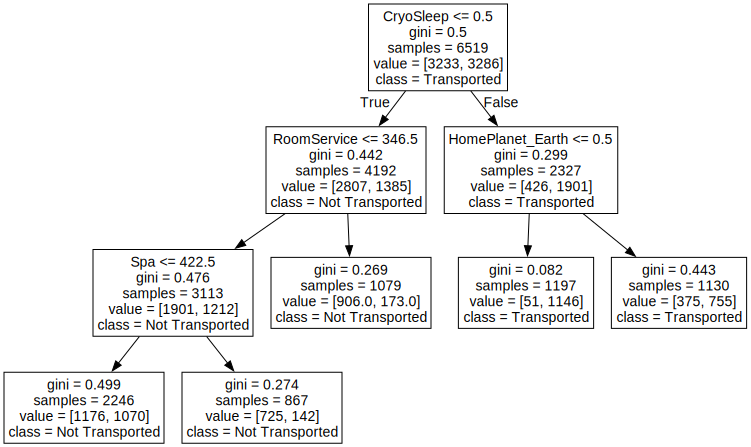

In [49]:
export_graphviz(cart, out_file='cart.dot', feature_names=X_names, class_names=y_names)

#CART tree
graphviz.Source.from_file('cart.dot')

- Root node: CryoSleep, primarily classified as Transported, gini of 0.5
- If CryoSleep = True, next node is RoomService which splits at a threshold of 346.5
- Over that threshold = Spa - splits at thr422.5
- If CryoSleep = True, next node is HomePlanet_Earth, gini of 0.299
- Regardless of planet, passengers still classified as Transported. But: low gini at 0.082 if not from Earth

In [50]:
y_cartpred = cart.predict(X_test)

In [51]:
#Confusion matrix

cm_cart = confusion_matrix(y_test, y_cartpred)
cm_cart

array([[927, 155],
       [439, 653]])

In [52]:
#Evaluation metrics variables

tn_cart = cm_cart[0][0]
fn_cart = cm_cart[1][0]
fp_cart = cm_cart[0][1]
tp_cart = cm_cart[1][1]

gt_cart = tn_cart + fn_cart + fp_cart + tp_cart

In [53]:
#Evaluation metrics

accuracy_cart = (tp_cart + tn_cart) / gt_cart
errorrate_cart = 1 - accuracy_cart
sensitivity_cart = tp_cart / (tp_cart + fn_cart)
specificity_cart = tn_cart / (tn_cart + fp_cart)
precision_cart = tp_cart / (tp_cart + fp_cart)
f1_cart = 2 * ((precision_cart * sensitivity_cart) / (precision_cart + sensitivity_cart))
f2_cart = 5 * ((precision_cart * sensitivity_cart) / ((4 * precision_cart) + sensitivity_cart))
f05_cart = 1.25 * ((precision_cart * sensitivity_cart) / ((0.25 * precision_cart) + sensitivity_cart))

### Logistic Regression

In [54]:
#Add constants

Xlog = sm.add_constant(X)
Xlog_test = sm.add_constant(X_test)

logreg01 = sm.Logit(y, Xlog).fit()

         Current function value: 0.437900
         Iterations: 35


In [55]:
y_logregpred_probabilities = logreg01.predict(Xlog_test)
y_logregpred = (y_logregpred_probabilities >= 0.5).astype(int)

In [56]:
#Confusion matrix

cm_logreg = confusion_matrix(y_test, y_logregpred)
cm_logreg

array([[818, 264],
       [214, 878]])

In [57]:
#Evaluation metrics variables

tn_logreg = cm_logreg[0][0]
fn_logreg = cm_logreg[1][0]
fp_logreg = cm_logreg[0][1]
tp_logreg = cm_logreg[1][1]

gt_logreg = tn_logreg + fn_logreg + fp_logreg + tp_logreg

In [58]:
# Evaluation metrics

accuracy_logreg = (tp_logreg + tn_logreg) / gt_logreg
errorrate_logreg = 1 - accuracy_logreg
sensitivity_logreg = tp_logreg / (tp_logreg + fn_logreg)
specificity_logreg = tn_logreg / (tn_logreg + fp_logreg)
precision_logreg = tp_logreg / (tp_logreg + fp_logreg)
f1_logreg = 2 * ((precision_logreg * sensitivity_logreg) / (precision_logreg + sensitivity_logreg))
f2_logreg = 5 * ((precision_logreg * sensitivity_logreg) / ((4 * precision_logreg) + sensitivity_logreg))
f05_logreg = 1.25 * ((precision_logreg * sensitivity_logreg) / ((0.25 * precision_logreg) + sensitivity_logreg))

### Naïve Bayes

In [59]:
#Creating Naive Bayes model

nb_01 = MultinomialNB().fit(X, y.values.ravel())
y_nbpred = nb_01.predict(X_test)
cm_nb = confusion_matrix(y_test, y_nbpred)

#Evaluation metrics variables

tn_nb = cm_nb[0][0]
fn_nb = cm_nb[1][0]
fp_nb = cm_nb[0][1]
tp_nb = cm_nb[1][1]

gt_nb = tn_nb + fn_nb + fp_nb + tp_nb

#Evaluation metrics

accuracy_nb = (tp_nb + tn_nb) / gt_nb
errorrate_nb = 1 - accuracy_nb
sensitivity_nb = tp_nb / (tp_nb + fn_nb)
specificity_nb = tn_nb / (tn_nb + fp_nb)
precision_nb = tp_nb / (tp_nb + fp_nb)
f1_nb = 2 * ((precision_nb * sensitivity_nb) / (precision_nb + sensitivity_nb))
f2_nb = 5 * ((precision_nb * sensitivity_nb) / ((4 * precision_nb) + sensitivity_nb))
f05_nb = 1.25 * ((precision_nb * sensitivity_nb) / ((0.25 * precision_nb) + sensitivity_nb))

In [60]:
#Printing confusion matrix and evaluation metrics

print("Confusion Matrix:")
print(cm_nb)
print()
print("Naive Bayes Results:")
print(f"Accuracy:    {accuracy_nb:.4f}")
print(f"Error Rate:  {errorrate_nb:.4f}")
print(f"Sensitivity: {sensitivity_nb:.4f}")
print(f"Specificity: {specificity_nb:.4f}")
print(f"Precision:   {precision_nb:.4f}")
print(f"F1:          {f1_nb:.4f}")
print(f"F2:          {f2_nb:.4f}")
print(f"F0.5:        {f05_nb:.4f}")

Confusion Matrix:
[[678 404]
 [106 986]]

Naive Bayes Results:
Accuracy:    0.7654
Error Rate:  0.2346
Sensitivity: 0.9029
Specificity: 0.6266
Precision:   0.7094
F1:          0.7945
F2:          0.8562
F0.5:        0.7411


In [ ]:
- Model is Multinomial Naive Bayes
- Accuracy is equal to 76.54% which correctly classifies about 77% of the passengers
- Confusion matrix depicts 678 true negatives, 986 true positives, 404 false positive, and 106 false negatives
- Specificity is at 62.66% which is the lowest, the model incorreclty classified many non-transported passengers
- Precision is 70.94% which means that when predicting wether transported, it was correct about 71% of the time
- F1 score is 0.795 which is a decent balance however it is important to note that sensitivity outweighs specificity

### C5.0

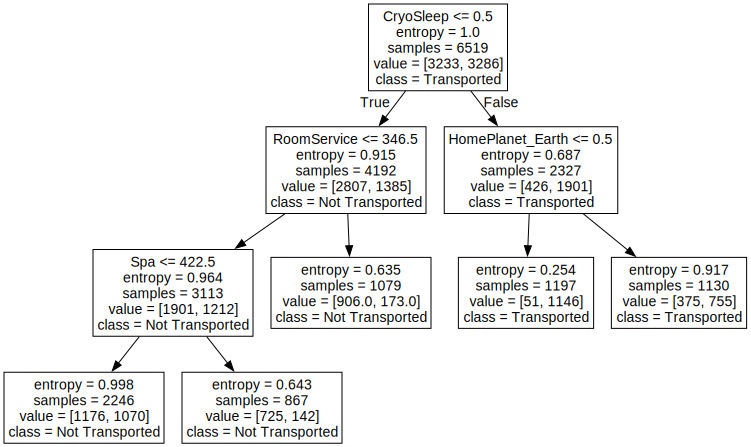

In [61]:
#Creating a C5.0 decision tree

X_names = list(X.columns)
y_names = ['Not Transported', 'Transported']

c50_01 = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=5, random_state=42).fit(X, y)

export_graphviz(c50_01, out_file='c50_01.dot', feature_names=X_names, class_names=y_names)
graphviz.Source.from_file('c50_01.dot')

- Root node: CryoSleep, primarily classified as Transported, entropy of 1
- If CryoSleep = True, next node is RoomService which splits at a threshold of 346.5
- Over that threshold = Spa - splits at threshold of 422.5
- If CryoSleep = True, next node is HomePlanet_Earth, entropy of 0.687
- Regardless of planet, passengers still classified as Transported. But: low entropy at 0.254 if not from Earth

In [62]:
y_c50pred = c50_01.predict(X_test)

In [63]:
cm_c50 = confusion_matrix(y_test, y_c50pred)

#Evaluation metrics variables

tn_c50 = cm_c50[0][0]
fn_c50 = cm_c50[1][0]
fp_c50 = cm_c50[0][1]
tp_c50 = cm_c50[1][1]

gt_c50 = tn_c50 + fn_c50 + fp_c50 + tp_c50

#Creating evaluation metrics

accuracy_c50 = (tp_c50 + tn_c50) / gt_c50
errorrate_c50 = 1 - accuracy_c50
sensitivity_c50 = tp_c50 / (tp_c50 + fn_c50)
specificity_c50 = tn_c50 / (tn_c50 + fp_c50)
precision_c50 = tp_c50 / (tp_c50 + fp_c50)
f1_c50 = 2 * ((precision_c50 * sensitivity_c50) / (precision_c50 + sensitivity_c50))
f2_c50 = 5 * ((precision_c50 * sensitivity_c50) / ((4 * precision_c50) + sensitivity_c50))
f05_c50 = 1.25 * ((precision_c50 * sensitivity_c50) / ((0.25 * precision_c50) + sensitivity_c50))

In [64]:
#Printing confusion matrix and evaluation metrics

print("Confusion Matrix:")
print(cm_c50)
print()
print("C5.0 Decision Tree Results:")
print(f"Accuracy:    {accuracy_c50:.4f}")
print(f"Error Rate:  {errorrate_c50:.4f}")
print(f"Sensitivity: {sensitivity_c50:.4f}")
print(f"Specificity: {specificity_c50:.4f}")
print(f"Precision:   {precision_c50:.4f}")
print(f"F1:          {f1_c50:.4f}")
print(f"F2:          {f2_c50:.4f}")
print(f"F0.5:        {f05_c50:.4f}")

Confusion Matrix:
[[927 155]
 [439 653]]

C5.0 Decision Tree Results:
Accuracy:    0.7268
Error Rate:  0.2732
Sensitivity: 0.5980
Specificity: 0.8567
Precision:   0.8082
F1:          0.6874
F2:          0.6308
F0.5:        0.7551


### Random Forest

In [65]:
#Creating Random Forest model

rfy = np.ravel(y)
rf01 = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42).fit(X, rfy)
y_rfpred = rf01.predict(X_test)

In [66]:
#Creating confusion matrix

cm_rf = confusion_matrix(y_test, y_rfpred)

#Creating evaluation metrics variables

tn_rf = cm_rf[0][0]
fn_rf = cm_rf[1][0]
fp_rf = cm_rf[0][1]
tp_rf = cm_rf[1][1]

gt_rf = tn_rf + fn_rf + fp_rf + tp_rf

#Evaluation metrics

accuracy_rf = (tp_rf + tn_rf) / gt_rf
errorrate_rf = 1 - accuracy_rf
sensitivity_rf = tp_rf / (tp_rf + fn_rf)
specificity_rf = tn_rf / (tn_rf + fp_rf)
precision_rf = tp_rf / (tp_rf + fp_rf)
f1_rf = 2 * ((precision_rf * sensitivity_rf) / (precision_rf + sensitivity_rf))
f2_rf = 5 * ((precision_rf * sensitivity_rf) / ((4 * precision_rf) + sensitivity_rf))
f05_rf = 1.25 * ((precision_rf * sensitivity_rf) / ((0.25 * precision_rf) + sensitivity_rf))

In [67]:
#Printing confusion matrix and evaluation metrics

print("Confusion Matrix:")
print(cm_rf)
print()
print("Random Forest Results:")
print(f"Accuracy:    {accuracy_rf:.4f}")
print(f"Error Rate:  {errorrate_rf:.4f}")
print(f"Sensitivity: {sensitivity_rf:.4f}")
print(f"Specificity: {specificity_rf:.4f}")
print(f"Precision:   {precision_rf:.4f}")
print(f"F1:          {f1_rf:.4f}")
print(f"F2:          {f2_rf:.4f}")
print(f"F0.5:        {f05_rf:.4f}")

Confusion Matrix:
[[884 198]
 [280 812]]

Random Forest Results:
Accuracy:    0.7801
Error Rate:  0.2199
Sensitivity: 0.7436
Specificity: 0.8170
Precision:   0.8040
F1:          0.7726
F2:          0.7549
F0.5:        0.7911


In [ ]:
- The model is a Random Forest approach with a total of 100 trees and Gini criterion
- Accuracy is 78.15% which is the highest accross all five models
Confusion matrix depicts 884 true negatives, 815 true positives, 198 false positives, and 277 false negatives
- Sensitivity is 74.63% which indicates that the model was good at identifiying transported passengers
- Specificity was 74.63% which means that the model was strong at identifying non-transported passengers
- Precisoin was at 80.45% which means that when predicting transported, it was correct about 80% of the time
- F1 score is 0.774 which is the highest score among all five models, this model had the overall best balance between precision and sensitivity
- All in all this model was the best overall based on accuracy and F1 score

### Model Comparison

In [68]:
#Model evaluation metrics comparison table

results = pd.DataFrame({'Baseline': [accuracy_base, 
                                     errorrate_base, 
                                     sensitivity_base,
                                     specificity_base,
                                     precision_base,
                                     f1_base,
                                     f2_base,
                                     f05_base], 
                        'CART': [accuracy_cart,
                                 errorrate_cart, 
                                 sensitivity_cart,
                                 specificity_cart,
                                 precision_cart,
                                 f1_cart,
                                 f2_cart,
                                 f05_cart],
                        'Logistic Regression': [accuracy_logreg,
                                                errorrate_logreg, 
                                                sensitivity_logreg,
                                                specificity_logreg,
                                                precision_logreg,
                                                f1_logreg,
                                                f2_logreg,
                                                f05_logreg], 
                        'C5.0': [accuracy_c50,
                                 errorrate_c50,
                                 sensitivity_c50,
                                 specificity_c50,
                                 precision_c50,
                                 f1_c50,
                                 f2_c50,
                                 f05_c50],
                       'Naive Bayes': [accuracy_nb,
                                       errorrate_nb,
                                       sensitivity_nb,
                                       specificity_nb,
                                       precision_nb,
                                       f1_nb,
                                       f2_nb,
                                       f05_nb],
                       'Random Forest': [accuracy_rf,
                                         errorrate_rf,
                                         sensitivity_rf,
                                         specificity_rf,
                                         precision_rf,
                                         f1_rf,
                                         f2_rf,
                                         f05_rf]}, 
                       index=['Accuracy', 'Error Rate', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'F2', 'F0.5']).round(3)
results 

,Baseline,CART,Logistic Regression,C5.0,Naive Bayes,Random Forest
Accuracy,0.502,0.727,0.780,0.727,0.765,0.780
Error Rate,0.498,0.273,0.220,0.273,0.235,0.220
Sensitivity,1.000,0.598,0.804,0.598,0.903,0.744
Specificity,0.000,0.857,0.756,0.857,0.627,0.817
Precision,0.502,0.808,0.769,0.808,0.709,0.804
F1,0.669,0.687,0.786,0.687,0.795,0.773
F2,0.835,0.631,0.797,0.631,0.856,0.755
F0.5,0.558,0.755,0.776,0.755,0.741,0.791


In [69]:
results.to_csv("comparison.csv", index=False)